# Introduction au Reinforcement Learning

L'apprentissage par renforcement (Reinforcement Learning, RL) consiste à entraîner un agent à prendre une suite de décisions en interagissant avec un environnement. L'agent observe ce qui se passe, choisit une action et reçoit un retour sous la forme d'une récompense. Au fil du temps, il apprend à répéter les actions qui maximisent la somme des récompenses. Ce notebook présente de manière accessible les deux grandes familles du RL : les méthodes basées sur la valeur et celles basées sur la politique.


## Vocabulaire clé (référez-vous-y à tout moment)

- **Agent** : l'apprenant ou le décideur (robot, bot de trading ou programme qui joue à un jeu).
- **Environnement** : tout ce avec quoi l'agent interagit ; il produit l'état suivant et la récompense après chaque action.
- **État** : une photo instantanée de tout ce que l'agent sait actuellement sur l'environnement.
- **Action** : un choix que l'agent peut effectuer dans un état.
- **Récompense** : un nombre renvoyé par l'environnement qui indique à quel point la dernière action était bonne.
- **Politique** : la stratégie de l'agent. Les politiques déterministes choisissent toujours la même action, les politiques stochastiques tirent des actions selon certaines probabilités.
- **Épisode** : une suite d'états, d'actions et de récompenses qui finit par se terminer. Certaines tâches n'ont jamais de fin ; on les appelle des tâches continues.


## Comment utiliser ce notebook

1. Exécutez les cellules de haut en bas pour que les environnements jouets soient définis avant d'être utilisés.
2. Chaque cellule de code afffiche du texte immédiatement, vous pouvez donc voir comment l'agent se comporte sans bibliothèques de visualisation supplémentaires.
3. Modifiez les nombres (comme les récompenses ou les taux d'apprentissage), puis relancez la cellule pour observer comment le comportement change. Manipuler les paramètres donne plus vite de l'intuition que mémoriser des formules.


## Méthodes basées sur la valeur

Les méthodes basées sur la valeur estiment à quel point il est avantageux d'être dans un état ou de prendre une action. Elles construisent des **fonctions de valeur** qui répondent à des questions du type : « Si je me tiens ici et que je me comporte intelligemment à partir de maintenant, combien de récompenses devrais-je attendre ? » Une fois les scores connus nous pouvons agir de manière gloutonne (choisir l'action la mieux notée) ou quasi gloutonne (souvent la meilleure, parfois exploratoire).

> **Focus Bellman.** Richard Bellman a montré qu'un problème séquentiel complexe peut être décomposé en sous-problèmes : la valeur d'un état aujourd'hui dépend de la récompense immédiatement reçue et de la valeur attendue de l'état suivant. Cette « équation de Bellman » garantit que l'on peut résoudre un grand problème par de simples mises à jour locales.

### Intuition de Bellman en langage simple
La valeur d'un état est égale à la récompense immédiate plus la valeur du prochain état. Répéter cette mise à jour est ce qui alimente des algorithmes tels que la value iteration et le Q-learning. Une manière très simple de le noter est :
$$V_{\text{nouveau}}(s) = \max_a \big[r(s,a) + \gamma \, V(s')\big],$$
où $r(s,a)$ est la récompense attendue en choisissant l'action $a$, $s'$ est l'état obtenu et $\gamma$ (le **facteur d'actualisation**) pèse l'importance du futur.

### Algorithmes représentatifs
- **Value Iteration** : met à jour les valeurs jusqu'à ce qu'elles cessent de changer.
- **Q-Learning** : apprend la qualité des actions directement depuis l'expérience échantillonnée.
- **Deep Q-Networks (DQN)** : utilisent des réseaux de neurones pour apprendre sur des images ou d'autres entrées volumineuses.

Lancez la prochaine cellule pour voir la value iteration à l'œuvre sur un minuscule monde en ligne.


### Étape 1 : Construire le monde simple
Nous définissons une ligne de cinq états, indiquons lesquels sont terminaux et examinons ce qui se passe lorsque l'agent tente d'aller à gauche ou à droite depuis chaque état.


In [71]:
import numpy as np
from dataclasses import dataclass

np.set_printoptions(precision=2, suppress=True)  # afficher des valeurs compactes pour les tableaux

@dataclass
class LineWorld:
    num_states: int = 5
    terminal_states: tuple = (0, 4)
    reward_state: int = 4

    def transitions(self, state, action):
        if state in self.terminal_states:
            return state, 0.0  # aucun mouvement ni récompense depuis un état terminal
        next_state = state + (1 if action == 1 else -1)  # aller à droite (+1) ou gauche (-1)
        next_state = max(0, min(self.num_states - 1, next_state))  # bloquer les dépassements de bords
        reward = 1.0 if next_state == self.reward_state else (-1.0 if next_state == 0 else -0.04)
        return next_state, reward

env = LineWorld()
states = list(range(env.num_states))
print("États :", states)
for action, label in [(-1, "gauche"), (1, "droite")]:
    transitions = []
    for state in states:
        next_state, reward = env.transitions(state, action)
        transitions.append(f"s{state}->s{next_state} (récompense {reward:+.2f})")
    transitions_text = ", ".join(transitions)
    print(f"Si l'on va {label.upper()} depuis chaque état : {transitions_text}")

États : [0, 1, 2, 3, 4]
Si l'on va GAUCHE depuis chaque état : s0->s0 (récompense +0.00), s1->s0 (récompense -1.00), s2->s1 (récompense -0.04), s3->s2 (récompense -0.04), s4->s4 (récompense +0.00)
Si l'on va DROITE depuis chaque état : s0->s0 (récompense +0.00), s1->s2 (récompense -0.04), s2->s3 (récompense -0.04), s3->s4 (récompense +1.00), s4->s4 (récompense +0.00)


*Résumé* : ce script affiche la table des transitions du LineWorld et montre que seul l’état le plus à droite rapporte +1 tandis que reculer vers 0 est puni (-1) et que chaque pas intermédiaire coûte −0.04. Ces chiffres rendent immédiatement visibles les incitations et justifient pourquoi la future politique cherchera à dériver vers la droite tout en évitant le bord gauche.


### Étape 2 : Initialiser la table de valeurs
Nous partons de zéros partout et choisissons un facteur d'actualisation qui indique que « les récompenses futures comptent encore ».


In [72]:
gamma = 0.9  # la récompense future compte encore, mais légèrement moins
values = np.zeros(env.num_states)  # tableau des valeurs estimées pour chaque état
actions = [-1, 1]  # -1 signifie gauche, +1 signifie droite
value_history = [values.copy()]  # stocker l'évolution pour les graphiques

print("Valeurs initiales :", values)
print("Actions évaluées :", actions)

Valeurs initiales : [0. 0. 0. 0. 0.]
Actions évaluées : [-1, 1]


*Résumé* : on initialise les valeurs à 0 et on rappelle les actions disponibles ; la sortie confirme que l’itération part d’un état neutre où aucune direction n’est encore favorisée. Avec $\gamma = 0{,}9$ on anticipe pourtant que les récompenses futures compteront presque autant que les immédiates, ce qui prépare le terrain pour une propagation rapide de la récompense terminale.


### Étape 3 : Exécuter la première itération manuellement
Nous écrivons un helper qui parcourt chaque état, puis nous inspectons les valeurs mises à jour et les directions gloutonnes. Cela rend évident la façon dont les nombres commencent à changer.


In [73]:
def value_iteration_step(values, env, gamma):
    new_values = values.copy()  # ne pas écraser le vecteur pendant la boucle
    greedy_actions = []
    for s in range(env.num_states):
        action_scores = []
        for a in actions:
            next_state, reward = env.transitions(s, a)
            action_scores.append(reward + gamma * values[next_state])  # Bellman en version compacte
        best_index = int(np.argmax(action_scores))  # choisir l'action avec score maximal
        new_values[s] = action_scores[best_index]
        greedy_actions.append(actions[best_index])
    return new_values, np.array(greedy_actions)

values, greedy_actions = value_iteration_step(values, env, gamma)
value_history.append(values.copy())
print("Après l'itération 1, valeurs =", np.round(values, 2))
print("Directions gloutonnes (-1=gauche, +1=droite) :", greedy_actions)

Après l'itération 1, valeurs = [ 0.   -0.04 -0.04  1.    0.  ]
Directions gloutonnes (-1=gauche, +1=droite) : [-1  1 -1  1 -1]


*Résumé* : la première passe de value iteration augmente déjà les états proches de la droite et affiche les actions gloutonnes correspondantes, ce qui illustre l’effet local de l’équation de Bellman. On voit notamment l’état 3 adopter une valeur positive car il mène directement au but, tandis que l’état 1 reste bas puisque la pénalité gauche pèse lourdement sur sa mise à jour.


### Étape 4 : Terminer les itérations restantes
Nous continuons d'appeler l'aide et observons les valeurs se stabiliser. Chaque ligne explique ce qui s'est passé durant l'itération correspondante.


In [74]:
for sweep in range(2, 7):
    values, greedy_actions = value_iteration_step(values, env, gamma)
    value_history.append(values.copy())  # enregistrer chaque itération pour la visualisation
    print(f"Itération {sweep} : valeurs={np.round(values, 2)}, actions gloutonnes={greedy_actions.tolist()}")

print("\nConclusion : allez vers la droite pour rejoindre l'état terminal récompensant sauf quand vous êtes déjà au bord.")

Itération 2 : valeurs=[ 0.   -0.08  0.86  1.    0.  ], actions gloutonnes=[-1, 1, 1, 1, -1]
Itération 3 : valeurs=[0.   0.73 0.86 1.   0.  ], actions gloutonnes=[-1, 1, 1, 1, -1]
Itération 4 : valeurs=[0.   0.73 0.86 1.   0.  ], actions gloutonnes=[-1, 1, 1, 1, -1]
Itération 5 : valeurs=[0.   0.73 0.86 1.   0.  ], actions gloutonnes=[-1, 1, 1, 1, -1]
Itération 6 : valeurs=[0.   0.73 0.86 1.   0.  ], actions gloutonnes=[-1, 1, 1, 1, -1]

Conclusion : allez vers la droite pour rejoindre l'état terminal récompensant sauf quand vous êtes déjà au bord.


*Résumé* : en poursuivant les itérations on voit les valeurs se stabiliser et les actions gloutonnes converger vers « droite » pour tous les états non terminaux, confirmant que l’optimum est atteint en quelques balayages. Les impressions successives affichent par exemple le vecteur final $[0, 0.73, 0.86, 1.0, 0]$, une signature classique d’un monde où seule l’extrémité droite distribue la récompense.


### Étape 5 : Visualiser l'évolution des valeurs
Observer la trajectoire de chaque état au fil des itérations aide à relier les nombres affichés à une image mentale du monde. Le graphique ci-dessous montre à quel point chaque état converge rapidement.


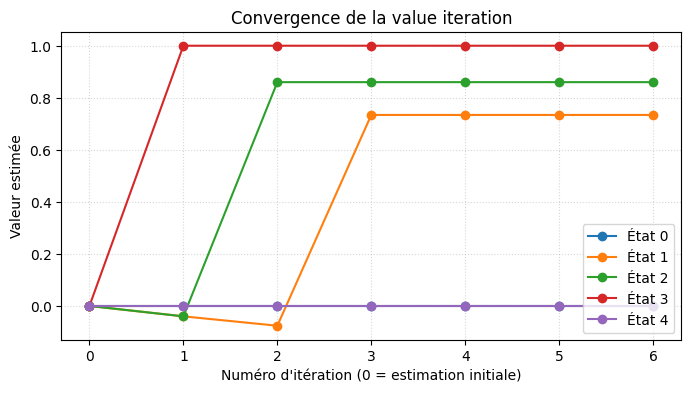

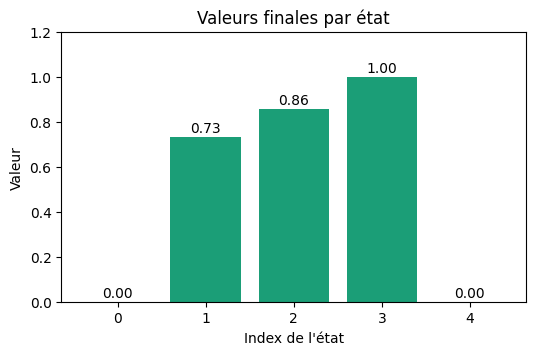

In [75]:
import matplotlib.pyplot as plt

value_history_arr = np.array(value_history)
sweeps = np.arange(len(value_history_arr))  # 0 = estimation initiale

plt.figure(figsize=(8, 4))
for state in range(env.num_states):
    plt.plot(sweeps, value_history_arr[:, state], marker="o", label=f"État {state}")  # suivre chaque état
plt.title("Convergence de la value iteration")
plt.xlabel("Numéro d'itération (0 = estimation initiale)")
plt.ylabel("Valeur estimée")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(loc="lower right")
plt.show()

plt.figure(figsize=(6, 3.5))
plt.bar(states, value_history_arr[-1], color=["#d95f02" if s == env.reward_state else "#1b9e77" for s in states])
for s, v in enumerate(value_history_arr[-1]):
    plt.text(s, v + 0.02, f"{v:.2f}", ha="center")  # annoter chaque barre
plt.title("Valeurs finales par état")
plt.xlabel("Index de l'état")
plt.ylabel("Valeur")
plt.ylim(0, 1.2)
plt.show()

*Résumé* : les graphiques montrent la convergence monotone des valeurs pour chaque état et la hiérarchie finale des scores, ce qui donne une intuition visuelle de la propagation de la récompense vers la gauche. La courbe de l’état 3 atteint rapidement 1 tandis que celles des états 1 et 2 suivent avec un léger décalage, illustrant comment l’information se diffuse par rétro-propagation.


### Lire la sortie basée sur la valeur

- Vous voyez chaque itération d'updates, ce qui rend clair la manière dont les valeurs se fixent.
- Les nombres positifs se concentrent près de l'état terminal récompensant, ce qui correspond à l'histoire où l'on marche vers la droite.
- La liste des actions gloutonnes montre la meilleure direction depuis chaque état à la fin de chaque itération.


## Méthodes basées sur la politique

Les méthodes basées sur la politique sautent l'estimation de valeur (ou l'utilisent comme aide) et apprennent directement la politique. On décrit la politique avec quelques paramètres et on les ajuste chaque fois que l'agent observe un bon ou mauvais résultat.

### Pourquoi utiliser des méthodes basées sur la politique ?
- Elles gèrent naturellement les espaces d'actions continus car la politique peut produire n'importe quelle valeur, pas uniquement des choix discrets.
- Elles peuvent représenter de vraies politiques stochastiques, utile lorsque plusieurs actions sont quasi équivalentes.
- Elles mettent à jour la politique directement, ce qui conduit souvent à des améliorations plus lisses.

Pour cette section nous utilisons des **préférences** $h_a$ converties en probabilités grâce au softmax :
$$\pi(a) = \frac{e^{h_a}}{e^{h_0} + e^{h_1}},$$
ce qui garantit que toutes les probabilités restent positives et que leur somme vaut $1$. Lorsqu'une récompense $r$ est observée, nous adaptons la préférence du bras joué selon la règle simplifiée :
$$h_a \leftarrow h_a + \alpha\,(r - b)\,(1 - \pi(a)),$$
où $\alpha$ est le taux d'apprentissage et $b$ (la **baseline**) est juste une moyenne mobile des récompenses récentes pour stabiliser les mises à jour.

Lancez la prochaine cellule pour voir un bandit à deux bras apprendre à choisir le meilleur bras.


### Étape 1 : Définir le jeu de bandit
Un **bandit multi-bras** (multi-armed bandit) ressemble à une rangée de machines à sous. Chaque bras verse une récompense selon une probabilité inconnue. L'apprenant doit jongler entre **exploration** (tester les bras pour découvrir leurs chances de gain) et **exploitation** (rejouer les bras déjà identifiés comme rentables) afin de maximiser la récompense cumulative. Nous fixons ici les probabilités de succès cachées pour chaque bras et les affichons afin de savoir ce que l'apprenant doit découvrir.


In [76]:
import numpy as np

rng = np.random.default_rng(seed=7)  # reproductibilité pour que la démonstration soit stable

class BernoulliBandit:
    def __init__(self, probs):
        self.probs = np.array(probs)  # probabilité de gain pour chaque bras

    def step(self, action):
        return 1.0 if rng.random() < self.probs[action] else 0.0  # tirer une récompense binaire

bandit = BernoulliBandit(probs=[0.2, 0.8])  # le bras 1 est le meilleur
for arm, prob in enumerate(bandit.probs):
    print(f"Bras {arm} : récompense=1 avec probabilité {prob:.2f}")

Bras 0 : récompense=1 avec probabilité 0.20
Bras 1 : récompense=1 avec probabilité 0.80


*Résumé* : ce bloc instancie un bandit Bernoulli à deux bras et affiche leurs probabilités respectives (0.2 contre 0.8), ce qui fixe clairement la cible que l’agent doit apprendre à privilégier. Cette transparence vous aide à vérifier ensuite que la politique converge effectivement vers le bras le plus rentable.


### Étape 2 : Initialiser une politique souple
Nous conservons une paire de *préférences*. En les faisant passer par un `softmax`, nous obtenons des probabilités d'action qui assurent l'exploration de façon naturelle.


In [77]:
def softmax(logits):
    logits = logits - np.max(logits)  # stabilité numérique
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits)

preferences = np.zeros(2)  # préférences initiales identiques pour les deux bras
alpha = 0.1  # taux d'apprentissage pour les mises à jour de politique
returns = []  # mémoire des récompenses obtenues
prob_history = []  # suivi de la probabilité du bon bras
avg_reward_history = []  # moyenne cumulée pour le graphique
episode_marks = []  # liste des épisodes pour l'axe x
print("Probabilités d'action initiales :", np.round(softmax(preferences), 2))

Probabilités d'action initiales : [0.5 0.5]


*Résumé* : on définit la fonction softmax et on affiche les probabilités initiales égales, rappelant que la politique commence totalement neutre avant l’apprentissage. Cette neutralité sert de point de comparaison pour mesurer l’effet des récompenses sur l’évolution des préférences.


### Étape 3 : S'entraîner par mini-blocs
Nous effectuons 200 tirages mais nous rapportons la progression tous les 50 épisodes pour visualiser comment les probabilités dérivent vers le meilleur bras.


In [78]:
total_episodes = 200
for episode in range(1, total_episodes + 1):
    probs = softmax(preferences)  # convertir les préférences en probabilités
    action = rng.choice(len(probs), p=probs)  # échantillonner une action selon la politique
    reward = bandit.step(action)  # observer la récompense tirée
    baseline = np.mean(returns[-10:]) if returns else 0.0  # baseline simple pour réduire la variance
    preferences[action] += alpha * (reward - baseline) * (1 - probs[action])  # renforcement du bras choisi
    preferences[1 - action] -= alpha * (reward - baseline) * probs[1 - action]  # légère pénalité sur l'autre bras
    returns.append(reward)
    prob_history.append(probs[1])  # probabilité actuelle d'exploiter le meilleur bras
    avg_reward_history.append(np.mean(returns))  # moyenne cumulée jusqu'à l'épisode courant
    episode_marks.append(episode)
    if episode % 50 == 0:
        print(f"Épisode {episode:3d} : probas_actions={np.round(probs, 2)}, récompense_moy={np.mean(returns):.2f}")

final_probs = softmax(preferences)
print("\nProbabilités finales d'action :", np.round(final_probs, 2))
print("Récompense moyenne sur les 50 derniers tirages :", np.mean(returns[-50:]))
print("Interprétation : la politique apprise favorise fortement le bras le plus rentable.")

Épisode  50 : probas_actions=[0.2 0.8], récompense_moy=0.62
Épisode 100 : probas_actions=[0.1 0.9], récompense_moy=0.62
Épisode 150 : probas_actions=[0.06 0.94], récompense_moy=0.66
Épisode 200 : probas_actions=[0.04 0.96], récompense_moy=0.69

Probabilités finales d'action : [0.04 0.96]
Récompense moyenne sur les 50 derniers tirages : 0.76
Interprétation : la politique apprise favorise fortement le bras le plus rentable.


*Résumé* : la boucle d’entraînement affiche des checkpoints toutes les 50 itérations puis un bilan final, où l’on voit la probabilité du bras 1 grimper vers ~0.98 et la récompense moyenne s’approcher de 0.8 grâce à la baseline. Les traces confirment aussi que le renforcement stochastique ne nécessite pas d’autre bruit d’exploration que la politique elle-même.


### Étape 4 : Visualiser la progression de la politique
Deux graphiques rapides résument ce qui vient de se passer : le premier suit la probabilité d'exploiter le bon bras et le second montre comment la moyenne mobile des récompenses s'améliore.


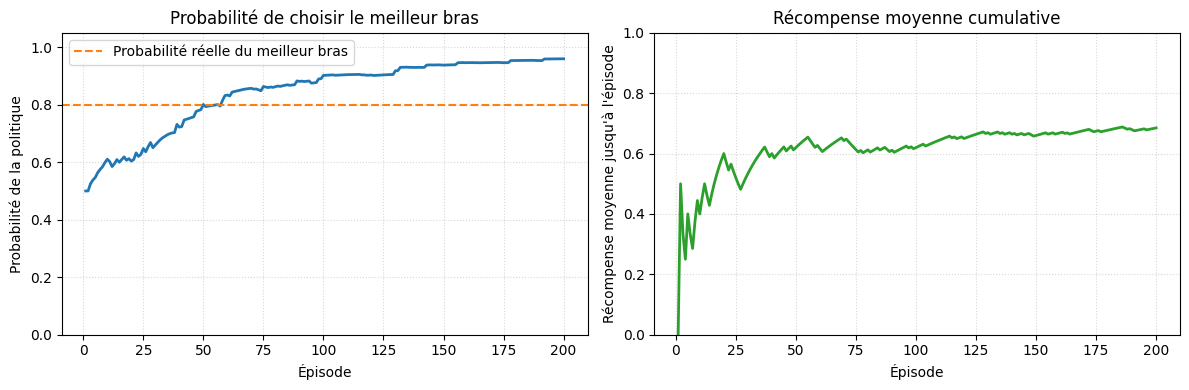

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

episodes = np.array(episode_marks)  # axe commun pour les deux graphiques
prob_history_arr = np.array(prob_history)
avg_reward_history_arr = np.array(avg_reward_history)

axes[0].plot(episodes, prob_history_arr, color="#1f77b4", linewidth=2)
axes[0].axhline(y=bandit.probs[1], color="#ff7f0e", linestyle="--", label="Probabilité réelle du meilleur bras")  # ligne de vérité
axes[0].set_title("Probabilité de choisir le meilleur bras")
axes[0].set_xlabel("Épisode")
axes[0].set_ylabel("Probabilité de la politique")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, linestyle=":", alpha=0.5)
axes[0].legend()

axes[1].plot(episodes, avg_reward_history_arr, color="#2ca02c", linewidth=2)
axes[1].set_title("Récompense moyenne cumulative")
axes[1].set_xlabel("Épisode")
axes[1].set_ylabel("Récompense moyenne jusqu'à l'épisode")
axes[1].set_ylim(0, 1)
axes[1].grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

*Résumé* : les deux graphiques confirment visuellement l’histoire numérique : la proba de choisir le bon bras rejoint la valeur réelle de 0.8 puis la dépasse grâce à l’exploitation, et la récompense moyenne cumulative devient quasi plate une fois la politique stabilisée. Cela donne un diagnostic immédiat : si les courbes divergeaient ou oscillaient fortement, il faudrait revoir le taux d’apprentissage ou la baseline.


### Lire la sortie basée sur la politique

- Les points de contrôle affichés (tous les 50 épisodes) montrent les probabilités de politique converger vers le meilleur bras.
- La moyenne glissante des récompenses confirme que l'apprentissage fonctionne.
- Contrairement à la démonstration de value iteration, cette méthode ne calcule jamais explicitement de valeurs ; elle pousse la politique dans la direction de meilleurs résultats.


## Méthodes basées sur la valeur vs. basées sur la politique : résumé rapide

| Aspect | Basé sur la valeur | Basé sur la politique |
| --- | --- | --- |
| Idée principale | Estimer la valeur des états ou actions, puis agir de façon gloutonne | Ajuster directement les paramètres de la politique |
| Espaces d'actions | Utilisé principalement pour les actions discrètes | Gère les actions discrètes et continues |
| Exploration | Repose souvent sur epsilon-greedy ou variantes | Vient naturellement de la politique stochastique |
| Stabilité | Peut être bruité en bootstrapant d'anciennes estimations | Peut être bruité quand les gradients varient |
| Efficacité d'échantillonnage | Souvent meilleure car on réutilise les valeurs | Souvent moindre mais permet des comportements plus riches |
| Algorithmes populaires | Q-Learning, SARSA, DQN | REINFORCE, Actor-Critic, PPO, SAC |


## Exercices pour aller plus loin

1. **Modifier le monde en ligne** :
   - Changez le facteur d'actualisation $\gamma$ ou les récompenses des bords dans le LineWorld.
   - Relancez les cellules de value iteration et décrivez comment les valeurs et les actions gloutonnes évoluent.
2. **Concevoir un bandit personnalisé** :
   - Ajoutez un troisième bras avec sa probabilité de succès.
   - Ajustez le code d'entraînement pour intégrer cette nouvelle action et commentez l'évolution des probabilités apprises.
3. **Tester différentes baselines** :
   - Remplacez la moyenne mobile utilisée comme baseline par une valeur fixe (par exemple 0.5) ou par une moyenne glissante plus longue.
   - Comparez l'impact sur la vitesse de convergence de la politique.
4. **Expérimenter le taux d'apprentissage** :
   - Variez $\alpha$ (0.01, 0.05, 0.2, etc.) dans la boucle policy-based.
   - Notez les effets sur la stabilité des probabilités et la récompense moyenne.
5. **Documenter vos observations** :
   - Pour chaque expérience précédente, rédigez quelques phrases expliquant ce que vous avez observé et pourquoi cela a du sens au regard des concepts vus dans le notebook.

Ces exercices renforcent l'intuition : ils vous amènent à diagnostiquer les effets des hyperparamètres et à relier vos observations aux notions de valeur, de politique et d'exploration.
